# Rabi ???Notebook ???

??????????????????????P1 ?????????????????? Rabi ????

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from qsim.ui.notebook import run_workflow, plot_default

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'examples' / 'backend.yaml').exists():
            return p
    raise FileNotFoundError('Cannot locate project root with pyproject.toml and examples/backend.yaml')

PROJECT_ROOT = find_project_root(Path.cwd())
BACKEND_PATH = (PROJECT_ROOT / 'examples' / 'backend.yaml').resolve()
OUT_ROOT = (PROJECT_ROOT / 'runs' / 'notebook' / 'rabi').resolve()
OUT_ROOT.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('BACKEND_PATH =', BACKEND_PATH)
print('OUT_ROOT =', OUT_ROOT)

PROJECT_ROOT = D:\超导量子计算机噪声抑制\qsim
BACKEND_PATH = D:\超导量子计算机噪声抑制\qsim\examples\backend.yaml
OUT_ROOT = D:\超导量子计算机噪声抑制\qsim\runs\notebook\rabi


In [2]:
qasm_rabi = '''
OPENQASM 3;
qubit[1] q;
bit[1] c;
x q[0];
measure q[0] -> c[0];
'''

print('Quantum Circuit (QASM):')
print(qasm_rabi)

Quantum Circuit (QASM):

OPENQASM 3;
qubit[1] q;
bit[1] c;
x q[0];
measure q[0] -> c[0];



In [8]:
durations = np.linspace(2.0, 120.0, 50)
p1 = []
sample_result = None

for i, d in enumerate(durations):
    hw = {
        'gate_duration': float(d),
        'dt': 0.25,
        'qubit_freqs_hz': [0.0],
        'control_scale': 0.25,
    }
    noise = {'gamma1': 0.0, 'gamma_phi': 0.01}
    result = run_workflow(
        qasm_text=qasm_rabi,
        backend_path=str(BACKEND_PATH),
        out_dir=str((OUT_ROOT / "debug_one").resolve()),
        hardware=hw,
        noise=noise,
        engine="qutip",
        persist_artifacts=False,
        export_dxf=False,   # 先关掉 dxf 看差异
    )
    
    for k, v in sorted(result["timings"].items(), key=lambda x: x[1], reverse=True):
        print(f"{k:16s} {v:.4f} s")

    p1.append(result['trace'].states[-1][0])
    if i == len(durations) // 2:
        sample_result = result

p1 = np.asarray(p1)

# ???????????? Rabi ????? sin^2 ??
step = float(durations[1] - durations[0])
freqs = np.fft.rfftfreq(len(durations), d=step)
spec = np.fft.rfft(p1 - p1.mean())
k = int(np.argmax(np.abs(spec[1:])) + 1) if len(spec) > 1 else 0
f0 = float(freqs[k]) if k > 0 else 0.0
if f0 > 0:
    p1_theory = 0.5 * (1.0 - np.cos(2.0 * np.pi * f0 * (durations - durations[0])))
else:
    p1_theory = np.full_like(durations, p1.mean())

print('Last run dir =', result['out_dir'])
print('Estimated dominant Rabi frequency =', f0)

total            0.1572 s
engine_run       0.1493 s
manifest_write   0.0062 s
backend_load     0.0007 s
analysis_run     0.0004 s
pulse_compile    0.0004 s
model_build      0.0001 s
qasm_parse       0.0000 s
lowering         0.0000 s
compile_pipeline 0.0000 s
pulse_npz_write  0.0000 s
timings_write    0.0000 s
artifact_write   0.0000 s
dxf_export       0.0000 s
total            0.0912 s
engine_run       0.0810 s
manifest_write   0.0081 s
backend_load     0.0011 s
analysis_run     0.0004 s
pulse_compile    0.0004 s
model_build      0.0001 s
lowering         0.0000 s
qasm_parse       0.0000 s
pulse_npz_write  0.0000 s
compile_pipeline 0.0000 s
timings_write    0.0000 s
artifact_write   0.0000 s
dxf_export       0.0000 s
total            0.0974 s
engine_run       0.0855 s
manifest_write   0.0103 s
backend_load     0.0007 s
pulse_compile    0.0004 s
analysis_run     0.0004 s
model_build      0.0001 s
qasm_parse       0.0000 s
lowering         0.0000 s
compile_pipeline 0.0000 s
pulse_npz_wr

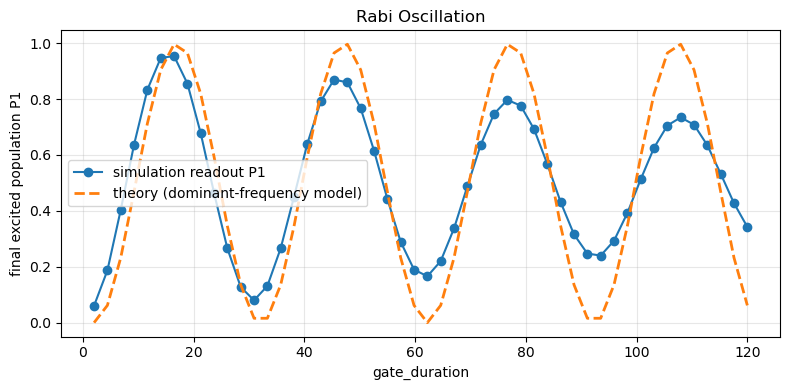

P1 min/max = 0.060644747631718655 0.9539016273387464


In [9]:
# ?? 1: ???? + ????
plt.figure(figsize=(8, 4))
plt.plot(durations, p1, 'o-', lw=1.5, label='simulation readout P1')
plt.plot(durations, p1_theory, '--', lw=2.0, label='theory (dominant-frequency model)')
plt.xlabel('gate_duration')
plt.ylabel('final excited population P1')
plt.title('Rabi Oscillation')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print('P1 min/max =', float(p1.min()), float(p1.max()))

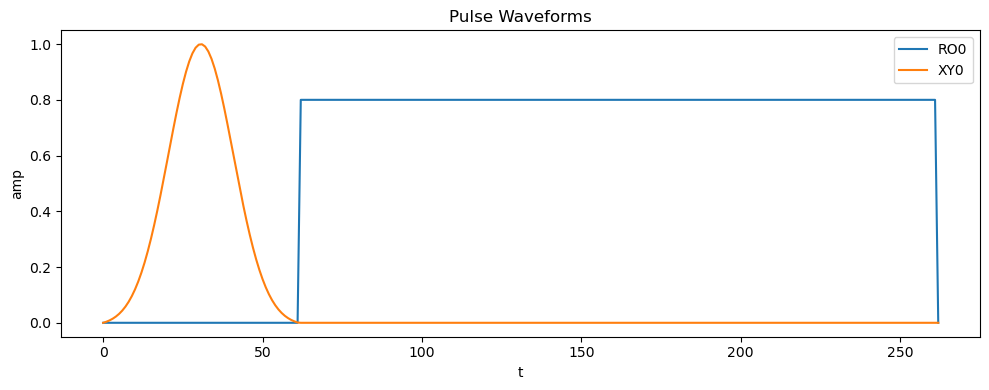

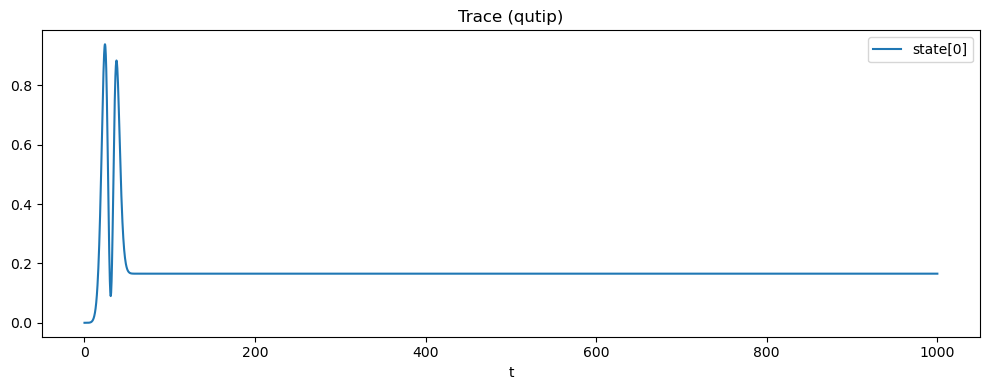

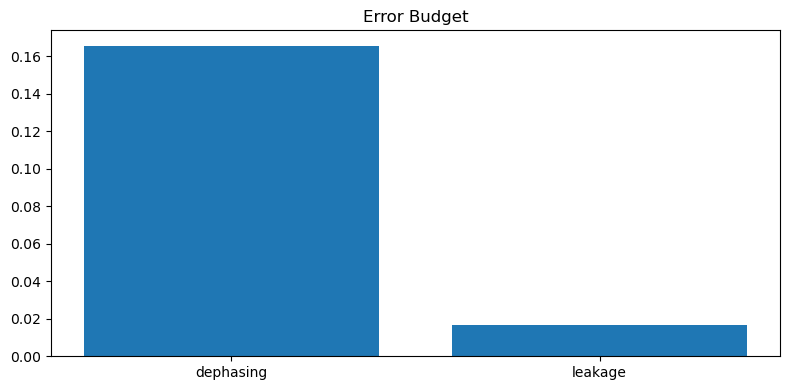

In [7]:
# ?? 2: ???????????????
figs = plot_default(sample_result)
# display(figs['pulses'])

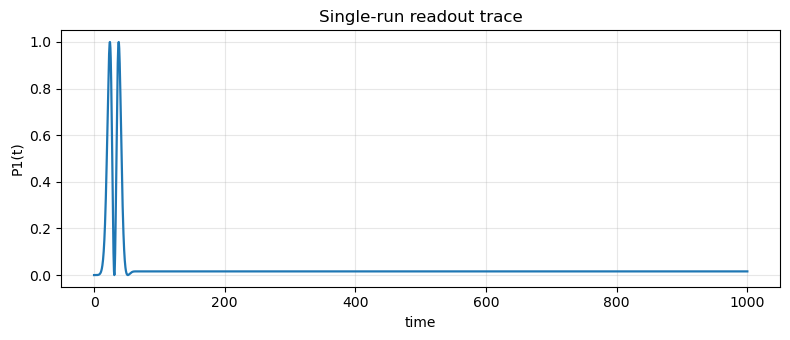

In [6]:
# ?? 3: ???????????readout time trace?
trace = sample_result['trace']
trace_p1 = np.asarray([row[0] for row in trace.states], dtype=float)

plt.figure(figsize=(8, 3.5))
plt.plot(trace.times, trace_p1, lw=1.6)
plt.xlabel('time')
plt.ylabel('P1(t)')
plt.title('Single-run readout trace')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import json

print('--- Settings Report ---')
print(json.dumps(result['settings'], ensure_ascii=False, indent=2))
print('--- Timings (s) ---')
for k, v in sorted(result['timings'].items(), key=lambda x: x[1], reverse=True):
    print(f'{k:16s} {v:.6f}')
